# 02 - Exploratory Data Analysis (EDA)
## Gender-Based Salary Gap Analysis

1. **Distribution through Occupation** - Show occupation-wise salary/earnings, compare male vs female
2. **Education and Salary** - Analyze education levels, salary changes with education, gender comparison
3. **Age and Employment** - Analyze age distribution, salary across age groups, employment status analysis
4. **Correlation Analysis** - Correlation matrix/heatmap for numerical variables

- Gender: Male, Female (not 1, 2)
- Occupation: Names from NCO (not 611, 522, etc.)
- Education: Category names (not numeric codes)
- Employment: Status descriptions (not 11, 21, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Load data
clean_df = pd.read_csv("../data/processed/clean_earners.csv")

# Load mappings
with open("../data/processed/mappings.json", "r") as f:
    mappings = json.load(f)

# Convert string keys back to appropriate types for mappings
gender_map = {int(k): v for k, v in mappings['gender'].items()}
education_map = {int(k): v for k, v in mappings['education_level'].items()}
employment_map = {int(k): v for k, v in mappings['employment_status'].items()}
occupation_map = {float(k): v for k, v in mappings['occupation'].items()}
industry_map = {float(k): v for k, v in mappings['industry'].items()}

print("✓ Data and mappings loaded successfully")
print(f"Dataset shape: {clean_df.shape}")
print(f"Columns: {list(clean_df.columns)}")

✓ Data and mappings loaded successfully
Dataset shape: (111977, 11)
Columns: ['gender', 'age', 'marital_status', 'education_level', 'formal_education_years', 'employment_status', 'industry', 'occupation', 'self_employed_earnings', 'regular_earnings', 'earnings']


# TASK 1: DISTRIBUTION THROUGH OCCUPATION

Analyze how workers are distributed across occupations and show salary differences by occupation and gender.

In [2]:
# Get top 15 occupations
top_occupations = clean_df['occupation'].value_counts().head(15)

print("Top 15 Occupations by Worker Count:")
print("="*60)
for occ_code, count in top_occupations.items():
    occ_name = occupation_map.get(occ_code, f"Code {occ_code}")
    print(f"{occ_name:<40} : {count:>6,} workers")

# Filter data to top occupations
top_occ_codes = set(top_occupations.index)
df_top_occ = clean_df[clean_df['occupation'].isin(top_occ_codes)].copy()

print(f"\nTotal workers in top 15 occupations: {len(df_top_occ):,} ({len(df_top_occ)/len(clean_df)*100:.1f}%)")

Top 15 Occupations by Worker Count:
General Farming                          : 18,881 workers
Retail Trade Workers                     : 12,287 workers
Helpers & Labourers (Manufacturing)      :  5,839 workers
Vegetable & Crop Farming                 :  5,567 workers
Corporate Managers                       :  3,635 workers
Machinery Mechanics                      :  3,479 workers
Fruit Farming                            :  3,113 workers
Cleaners & Helpers (Agriculture)         :  2,740 workers
Personal Care Workers                    :  2,626 workers
Accountants                              :  2,336 workers
Food Preparation Assistants              :  2,225 workers
Office Clerks                            :  1,815 workers
Welders & Flame Cutters                  :  1,772 workers
Drivers & Mobile Plant Operators         :  1,751 workers
Electricians                             :  1,742 workers

Total workers in top 15 occupations: 69,808 (62.3%)


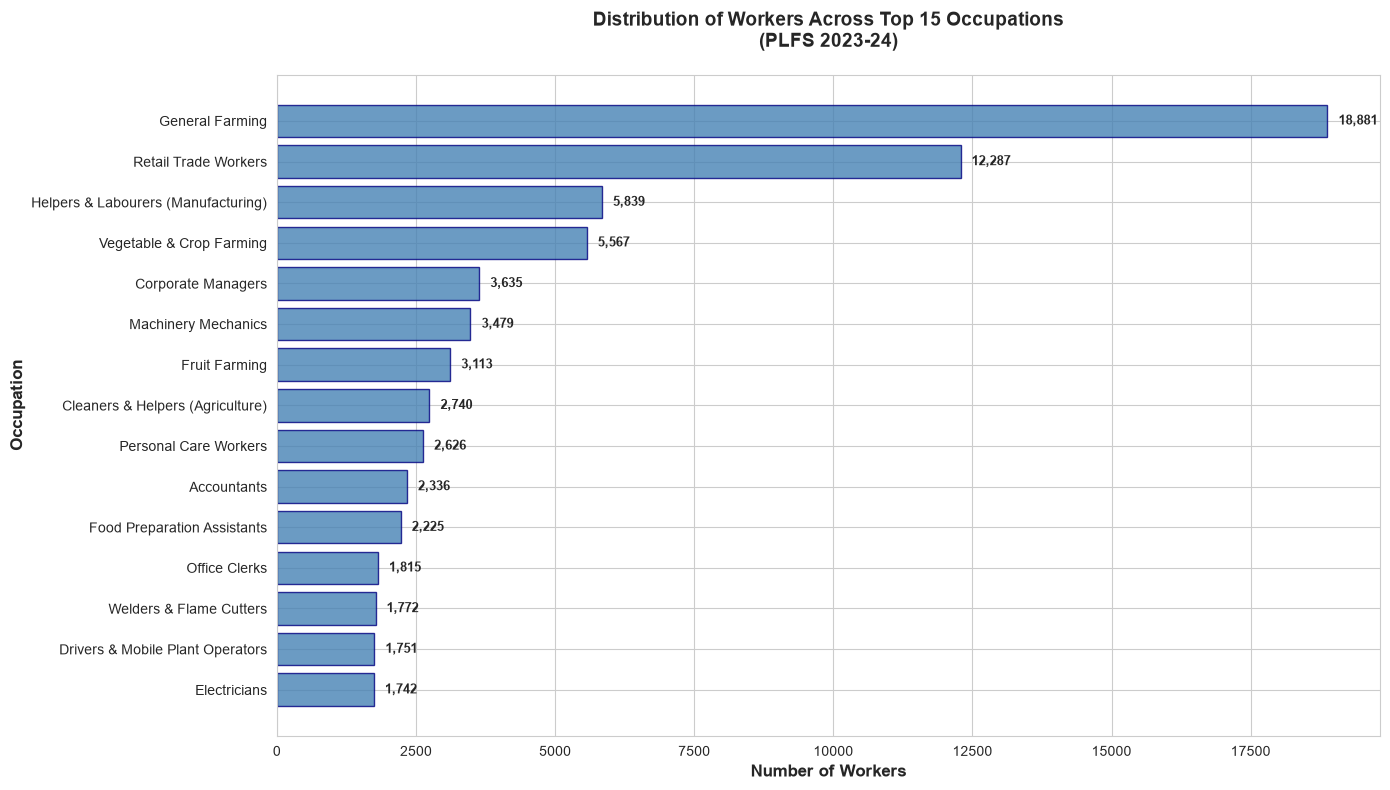

✓ Plot saved: 01_occupation_distribution.png


In [3]:
# Plot 1: Occupation Distribution - Count of Workers
fig, ax = plt.subplots(figsize=(14, 8))

# Map occupation codes to names
occ_names = [occupation_map.get(code, f"Code {code}") for code in top_occupations.index]
occ_counts = top_occupations.values

bars = ax.barh(occ_names, occ_counts, color='steelblue', edgecolor='navy', alpha=0.8)

# Add value labels
for i, (name, count) in enumerate(zip(occ_names, occ_counts)):
    ax.text(count + 200, i, f'{count:,}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Number of Workers', fontsize=12, fontweight='bold')
ax.set_ylabel('Occupation', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Workers Across Top 15 Occupations\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/01_occupation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 01_occupation_distribution.png")

In [4]:
# Occupation-wise earnings statistics
occ_earnings = df_top_occ.groupby('occupation')['earnings'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std')
]).round(2)

# Add occupation names
occ_earnings['Occupation'] = occ_earnings.index.map(lambda x: occupation_map.get(x, f"Code {x}"))
occ_earnings = occ_earnings[['Occupation', 'Count', 'Mean', 'Median', 'Std Dev']]
occ_earnings = occ_earnings.sort_values('Median', ascending=False)

print("\nOccupation-wise Earnings (Top 15 Occupations):")
print("="*100)
print(occ_earnings.to_string(index=False))


Occupation-wise Earnings (Top 15 Occupations):
                         Occupation  Count     Mean  Median  Std Dev
                      Office Clerks   1815 30370.99 30000.0 15667.39
                 Corporate Managers   3635 33165.18 25000.0 31514.53
                        Accountants   2336 26453.05 22000.0 19176.79
              Personal Care Workers   2626 26633.70 20000.0 18044.14
   Drivers & Mobile Plant Operators   1751 17528.04 15000.0  8752.59
Helpers & Labourers (Manufacturing)   5839 15686.62 15000.0  6880.51
                       Electricians   1742 16590.98 15000.0 11419.93
               Retail Trade Workers  12287 16082.11 14000.0 11052.14
        Food Preparation Assistants   2225 12081.81 12000.0  6046.70
                    General Farming  18881 12862.84 11000.0  9302.14
                      Fruit Farming   3113 11783.95 10000.0  8060.16
            Welders & Flame Cutters   1772 10652.33  8500.0  8398.78
                Machinery Mechanics   3479  9271.88  80

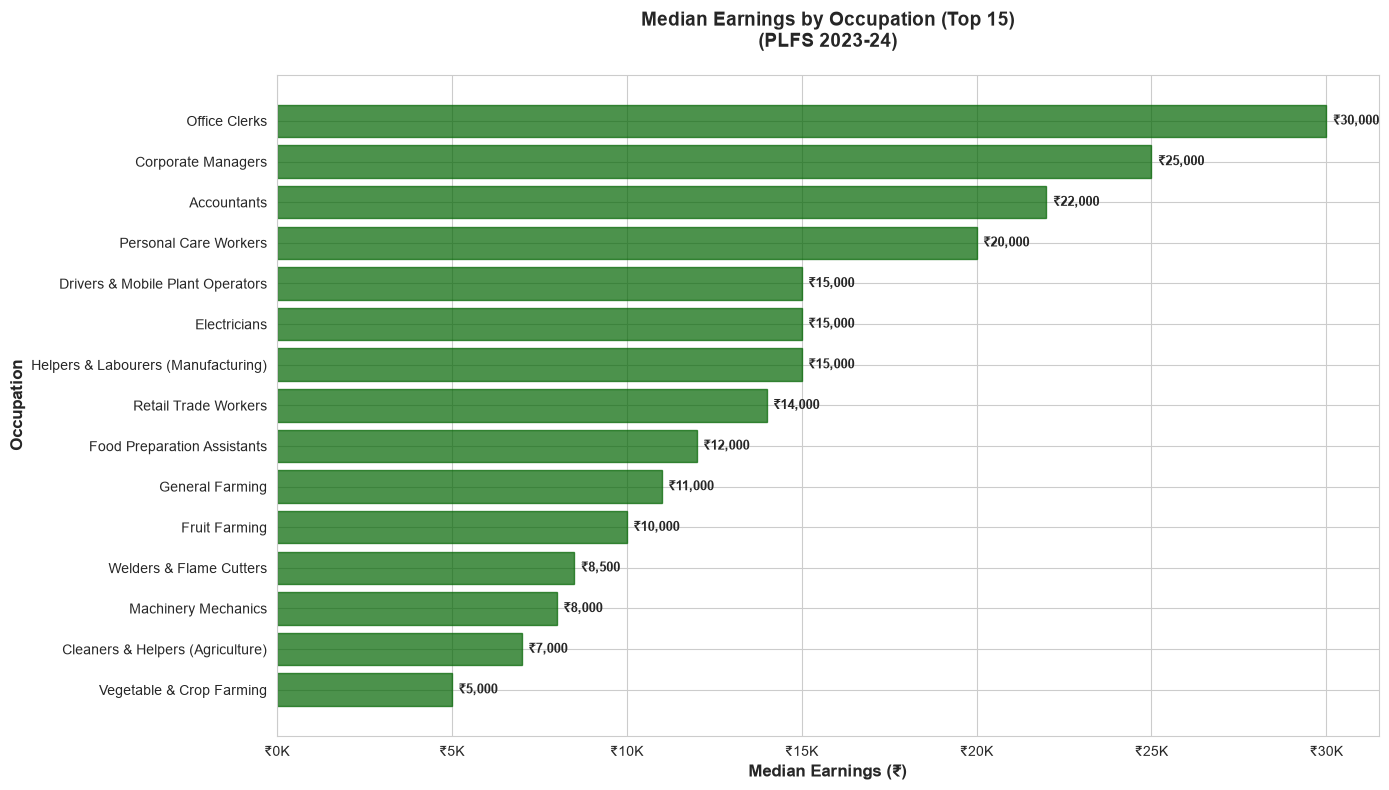

✓ Plot saved: 02_occupation_earnings.png


In [5]:
# Plot 2: Median Earnings by Occupation
fig, ax = plt.subplots(figsize=(14, 8))

occ_median = df_top_occ.groupby('occupation')['earnings'].median().sort_values(ascending=True)
occ_names_sorted = [occupation_map.get(code, f"Code {code}") for code in occ_median.index]

bars = ax.barh(occ_names_sorted, occ_median.values, color='darkgreen', edgecolor='darkgreen', alpha=0.7)

# Add value labels
for i, (name, value) in enumerate(zip(occ_names_sorted, occ_median.values)):
    ax.text(value + 200, i, f'₹{value:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Occupation', fontsize=12, fontweight='bold')
ax.set_title('Median Earnings by Occupation (Top 15)\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/02_occupation_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 02_occupation_earnings.png")

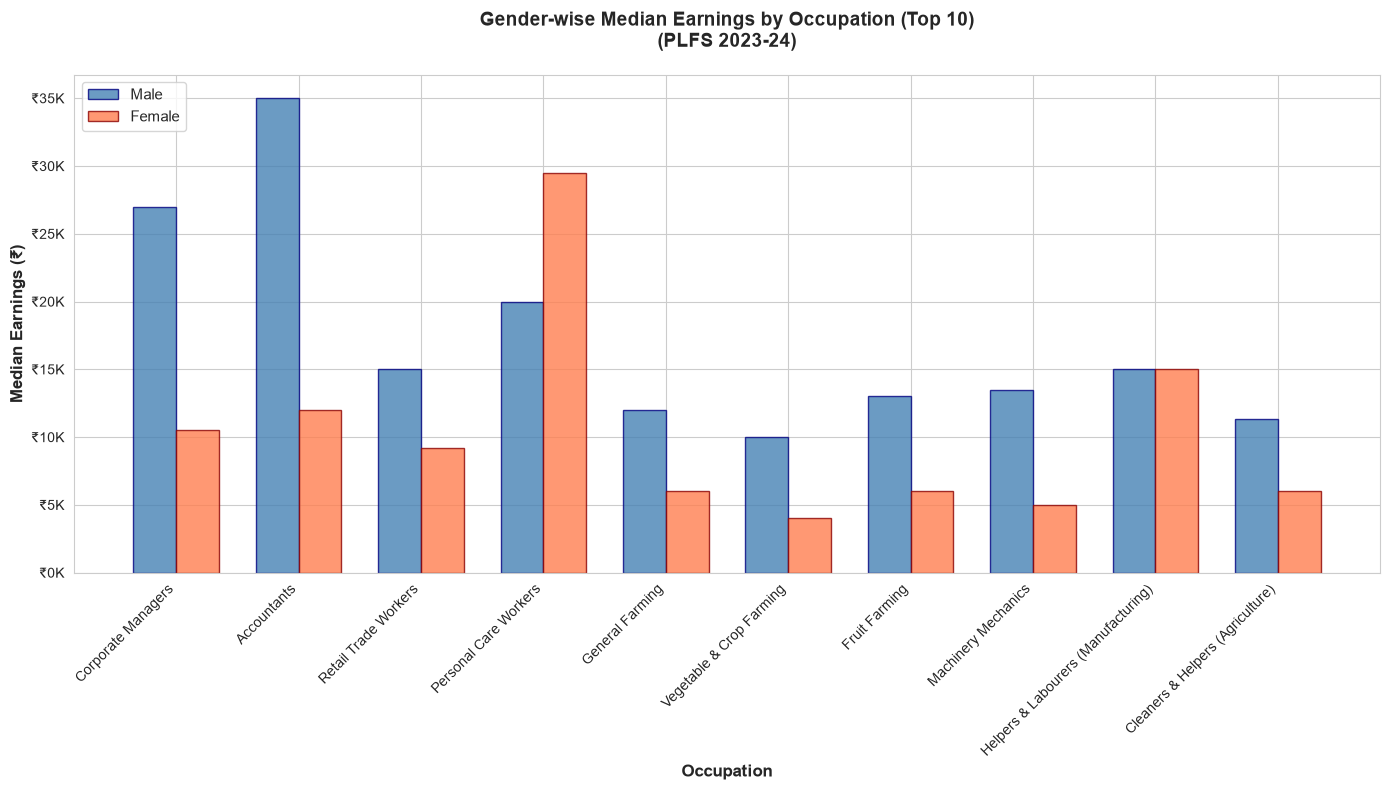

✓ Plot saved: 03_occupation_gender_earnings.png


In [6]:
# Plot 3: Occupation-wise Earnings Comparison by Gender
fig, ax = plt.subplots(figsize=(14, 8))

# Get median earnings by occupation and gender for top 10 occupations
top_occ_10 = clean_df['occupation'].value_counts().head(10).index
df_top10 = df_top_occ[df_top_occ['occupation'].isin(top_occ_10)]

occ_gender_earnings = df_top10.groupby(['occupation', 'gender'])['earnings'].median().unstack(fill_value=0)
occ_names_10 = [occupation_map.get(code, f"Code {code}") for code in occ_gender_earnings.index]

x = np.arange(len(occ_names_10))
width = 0.35

# Plot bars
if 1 in occ_gender_earnings.columns:
    bars1 = ax.bar(x - width/2, occ_gender_earnings[1], width, label='Male', color='steelblue', edgecolor='navy', alpha=0.8)
if 2 in occ_gender_earnings.columns:
    bars2 = ax.bar(x + width/2, occ_gender_earnings[2], width, label='Female', color='coral', edgecolor='darkred', alpha=0.8)

ax.set_xlabel('Occupation', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Gender-wise Median Earnings by Occupation (Top 10)\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(occ_names_10, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/03_occupation_gender_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 03_occupation_gender_earnings.png")

In [7]:
# Gender wage gap by occupation
occ_gender_earnings_sorted = occ_gender_earnings.sort_values(1, ascending=False)
occ_names_sorted = [occupation_map.get(code, f"Code {code}") for code in occ_gender_earnings_sorted.index]

gap_data = []
for occ_code in occ_gender_earnings_sorted.index:
    occ_name = occupation_map.get(occ_code, f"Code {occ_code}")
    male_earn = occ_gender_earnings_sorted.loc[occ_code, 1] if 1 in occ_gender_earnings_sorted.columns else 0
    female_earn = occ_gender_earnings_sorted.loc[occ_code, 2] if 2 in occ_gender_earnings_sorted.columns else 0
    
    if male_earn > 0:
        gap_pct = ((male_earn - female_earn) / male_earn) * 100
    else:
        gap_pct = 0
    
    gap_data.append({
        'Occupation': occ_name,
        'Male Median': male_earn,
        'Female Median': female_earn,
        'Gap (₹)': male_earn - female_earn,
        'Gap (%)': gap_pct
    })

gap_df = pd.DataFrame(gap_data)

print("\nGender Earnings Gap by Occupation (Top 10):")
print("="*80)
print(gap_df.to_string(index=False))


Gender Earnings Gap by Occupation (Top 10):
                         Occupation  Male Median  Female Median  Gap (₹)    Gap (%)
                        Accountants      35000.0        12000.0  23000.0  65.714286
                 Corporate Managers      27000.0        10500.0  16500.0  61.111111
              Personal Care Workers      20000.0        29500.0  -9500.0 -47.500000
               Retail Trade Workers      15000.0         9200.0   5800.0  38.666667
Helpers & Labourers (Manufacturing)      15000.0        15000.0      0.0   0.000000
                Machinery Mechanics      13500.0         5000.0   8500.0  62.962963
                      Fruit Farming      13000.0         6000.0   7000.0  53.846154
                    General Farming      12000.0         6000.0   6000.0  50.000000
   Cleaners & Helpers (Agriculture)      11350.0         6000.0   5350.0  47.136564
           Vegetable & Crop Farming      10000.0         4060.0   5940.0  59.400000


# TASK 2: EDUCATION AND SALARY

Analyze education levels and how salary changes with education, comparing male vs female.

In [8]:
# Education level distribution
edu_dist = clean_df['education_level'].value_counts().sort_index()

print("\nEducation Level Distribution:")
print("="*60)
for edu_code, count in edu_dist.items():
    edu_name = education_map.get(edu_code, f"Code {edu_code}")
    pct = (count / len(clean_df)) * 100
    print(f"{edu_name:<35} : {count:>6,} ({pct:>5.1f}%)")


Education Level Distribution:
Not Literate                        : 14,421 ( 12.9%)
Literate Without Formal Schooling   :    105 (  0.1%)
Below Primary                       :      2 (  0.0%)
Primary                             :     36 (  0.0%)
Middle                              :  5,034 (  4.5%)
Matric/10th                         : 13,281 ( 11.9%)
Higher Secondary/12th               : 24,827 ( 22.2%)
Diploma/Certificate                 : 15,740 ( 14.1%)
Graduate                            : 13,619 ( 12.2%)
Post Graduate                       :  2,570 (  2.3%)
Other Education                     : 16,693 ( 14.9%)
Technical Education                 :  5,649 (  5.0%)


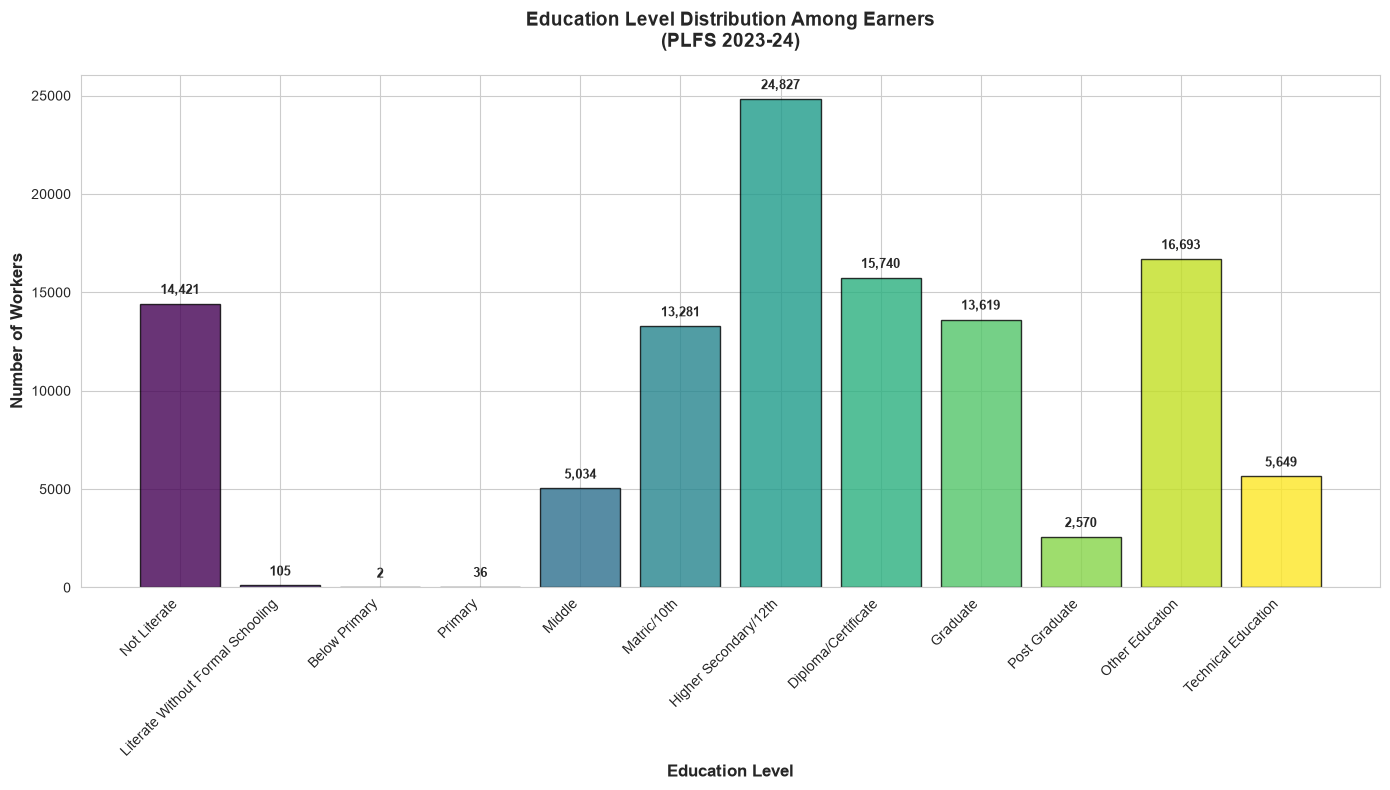

✓ Plot saved: 04_education_distribution.png


In [9]:
# Plot 4: Education Level Distribution
fig, ax = plt.subplots(figsize=(14, 8))

edu_names = [education_map.get(code, f"Code {code}") for code in edu_dist.index]
edu_counts = edu_dist.values

colors = plt.cm.viridis(np.linspace(0, 1, len(edu_names)))
bars = ax.bar(range(len(edu_names)), edu_counts, color=colors, edgecolor='black', alpha=0.8)

# Add value labels
for i, (name, count) in enumerate(zip(edu_names, edu_counts)):
    ax.text(i, count + 500, f'{count:,}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Education Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Workers', fontsize=12, fontweight='bold')
ax.set_title('Education Level Distribution Among Earners\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(edu_names)))
ax.set_xticklabels(edu_names, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/04_education_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 04_education_distribution.png")

In [10]:
# Education-wise earnings statistics
edu_earnings = clean_df.groupby('education_level')['earnings'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std')
]).round(2)

edu_earnings['Education'] = edu_earnings.index.map(lambda x: education_map.get(x, f"Code {x}"))
edu_earnings = edu_earnings[['Education', 'Count', 'Mean', 'Median', 'Std Dev']]
edu_earnings = edu_earnings.sort_values('Median', ascending=False)

print("\nEducation-wise Earnings Statistics:")
print("="*100)
print(edu_earnings.to_string(index=False))


Education-wise Earnings Statistics:
                        Education  Count     Mean  Median  Std Dev
              Technical Education   5649 38551.03 33600.0 29831.99
                  Other Education  16693 28789.67 22980.0 23529.14
                    Post Graduate   2570 23399.91 18000.0 18949.52
                         Graduate  13619 18287.37 15000.0 15071.64
              Diploma/Certificate  15740 15972.89 13500.0 12153.36
            Higher Secondary/12th  24827 14102.62 12000.0 10667.50
                      Matric/10th  13281 12480.57 11000.0  9076.44
                          Primary     36 10690.86  9500.0  7990.57
                           Middle   5034 11481.48  9500.0  9370.54
Literate Without Formal Schooling    105 11657.05  9000.0  8602.33
                     Not Literate  14421 10071.47  8000.0  8241.26
                    Below Primary      2  4250.00  4250.0  2474.87


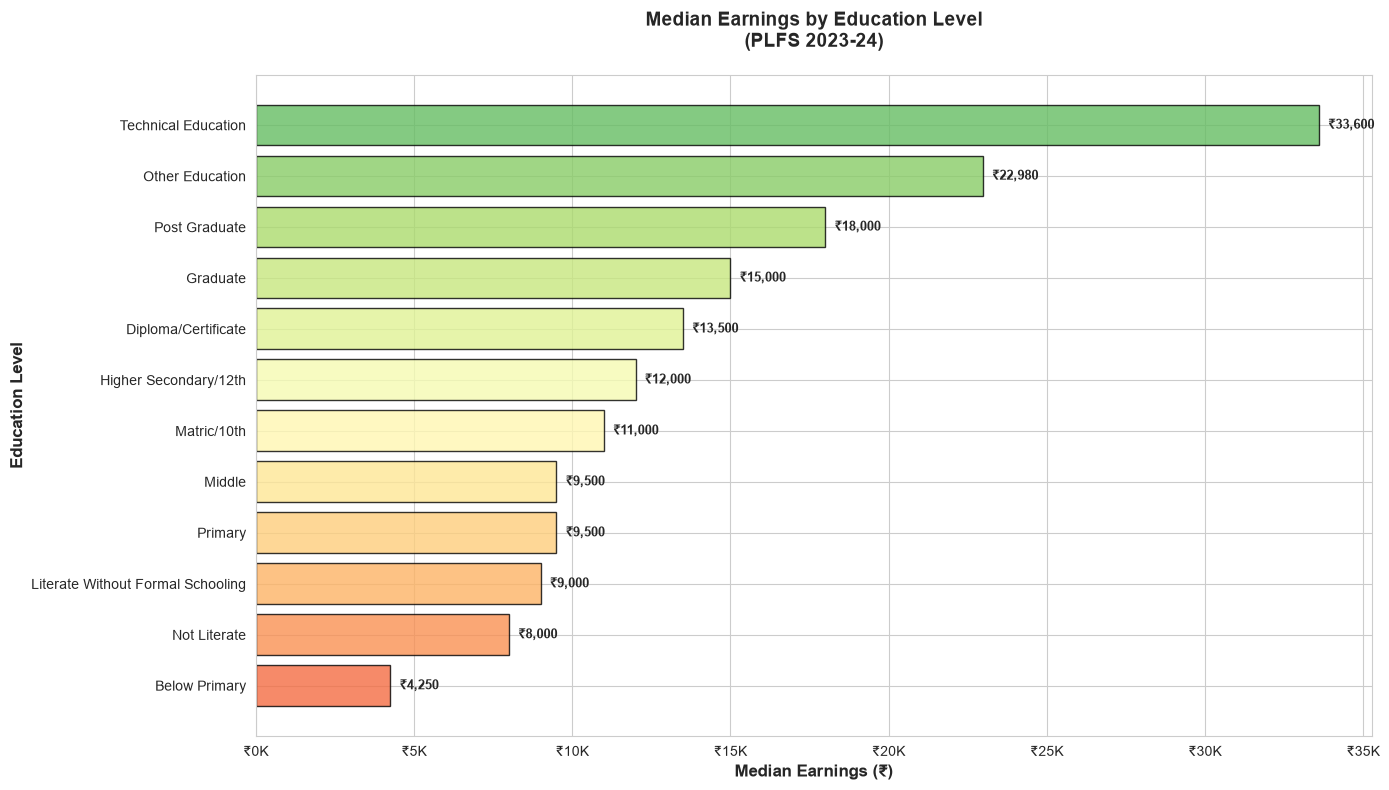

✓ Plot saved: 05_education_earnings.png


In [11]:
# Plot 5: Salary by Education Level
fig, ax = plt.subplots(figsize=(14, 8))

edu_median = clean_df.groupby('education_level')['earnings'].median().sort_values()
edu_names_sorted = [education_map.get(code, f"Code {code}") for code in edu_median.index]

colors_gradient = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(edu_median)))
bars = ax.barh(edu_names_sorted, edu_median.values, color=colors_gradient, edgecolor='black', alpha=0.8)

# Add value labels
for i, (name, value) in enumerate(zip(edu_names_sorted, edu_median.values)):
    ax.text(value + 300, i, f'₹{value:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Education Level', fontsize=12, fontweight='bold')
ax.set_title('Median Earnings by Education Level\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/05_education_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 05_education_earnings.png")

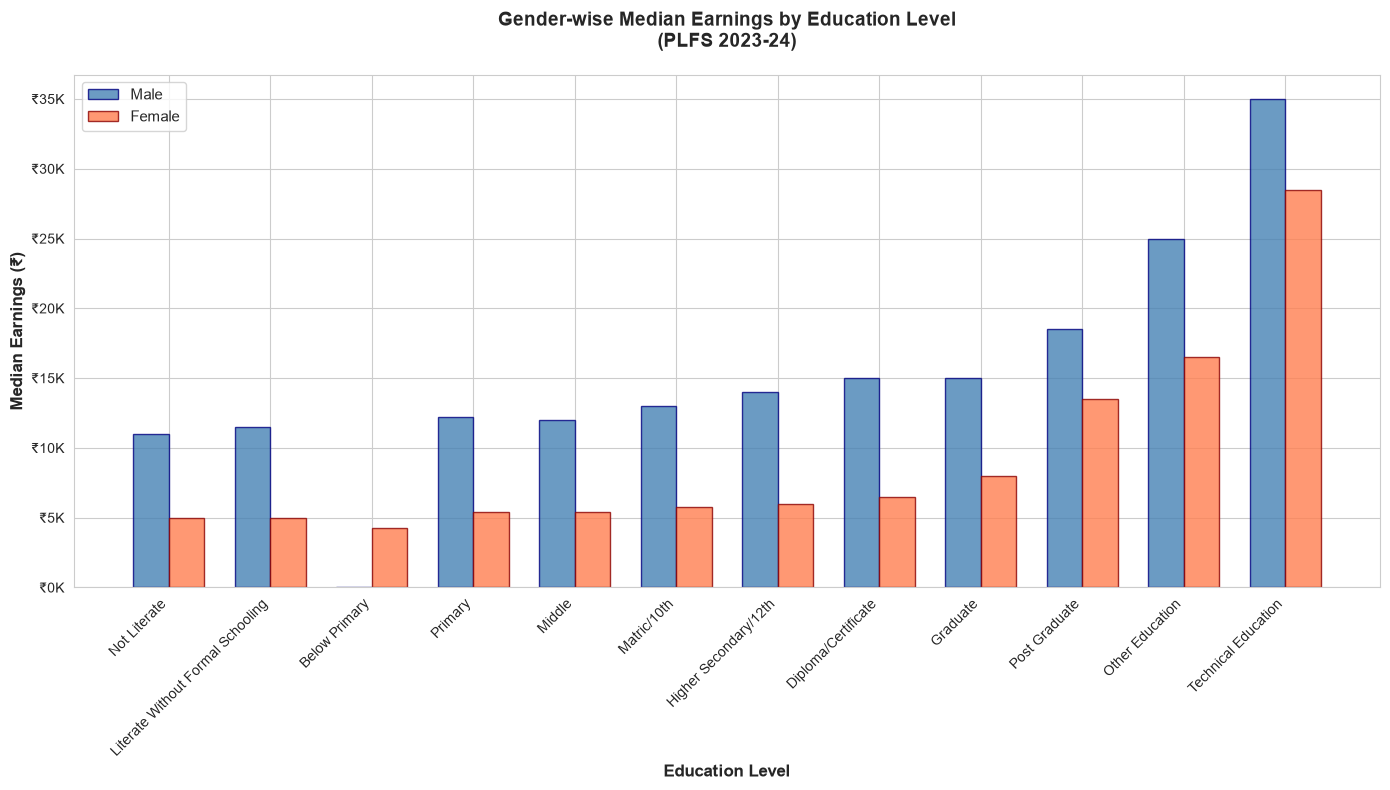

✓ Plot saved: 06_education_gender_earnings.png


In [12]:
# Plot 6: Gender-wise Earnings by Education Level
fig, ax = plt.subplots(figsize=(14, 8))

edu_gender = clean_df.groupby(['education_level', 'gender'])['earnings'].median().unstack(fill_value=0)
edu_names_all = [education_map.get(code, f"Code {code}") for code in edu_gender.index]

x = np.arange(len(edu_names_all))
width = 0.35

if 1 in edu_gender.columns:
    bars1 = ax.bar(x - width/2, edu_gender[1], width, label='Male', color='steelblue', edgecolor='navy', alpha=0.8)
if 2 in edu_gender.columns:
    bars2 = ax.bar(x + width/2, edu_gender[2], width, label='Female', color='coral', edgecolor='darkred', alpha=0.8)

ax.set_xlabel('Education Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Gender-wise Median Earnings by Education Level\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(edu_names_all, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/06_education_gender_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 06_education_gender_earnings.png")

In [13]:
# Gender earnings gap by education
print("\nGender Earnings Gap by Education Level:")
print("="*90)

gap_by_edu = []
for edu_code in sorted(edu_gender.index):
    edu_name = education_map.get(edu_code, f"Code {edu_code}")
    male_earn = edu_gender.loc[edu_code, 1] if 1 in edu_gender.columns else 0
    female_earn = edu_gender.loc[edu_code, 2] if 2 in edu_gender.columns else 0
    
    if male_earn > 0:
        gap_pct = ((male_earn - female_earn) / male_earn) * 100
    else:
        gap_pct = 0
    
    gap_by_edu.append({
        'Education': edu_name,
        'Male Median': male_earn,
        'Female Median': female_earn,
        'Gap (₹)': male_earn - female_earn,
        'Gap (%)': gap_pct
    })

gap_edu_df = pd.DataFrame(gap_by_edu)
print(gap_edu_df.to_string(index=False))


Gender Earnings Gap by Education Level:
                        Education  Male Median  Female Median  Gap (₹)   Gap (%)
                     Not Literate      11000.0         5000.0   6000.0 54.545455
Literate Without Formal Schooling      11500.0         5000.0   6500.0 56.521739
                    Below Primary          0.0         4250.0  -4250.0  0.000000
                          Primary      12250.0         5400.0   6850.0 55.918367
                           Middle      12000.0         5400.0   6600.0 55.000000
                      Matric/10th      13000.0         5800.0   7200.0 55.384615
            Higher Secondary/12th      14000.0         6000.0   8000.0 57.142857
              Diploma/Certificate      15000.0         6500.0   8500.0 56.666667
                         Graduate      15000.0         8000.0   7000.0 46.666667
                    Post Graduate      18500.0        13500.0   5000.0 27.027027
                  Other Education      25000.0        16500.0   8500

# TASK 3: AGE AND EMPLOYMENT

Analyze age distribution, salary across age groups, employment status distribution, and earnings by employment status.

In [14]:
# Create age groups
age_bins = [0, 20, 30, 40, 50, 60, 70, 100]
age_labels = ['11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+']

clean_df['age_group'] = pd.cut(clean_df['age'], bins=age_bins, labels=age_labels, right=False)

print("\nAge Group Distribution:")
print("="*60)
age_dist = clean_df['age_group'].value_counts().sort_index()
for age_group, count in age_dist.items():
    pct = (count / len(clean_df)) * 100
    print(f"Age {age_group} : {count:>6,} ({pct:>5.1f}%)")

print(f"\nOverall Age Statistics:")
print(f"  Mean age: {clean_df['age'].mean():.1f} years")
print(f"  Median age: {clean_df['age'].median():.1f} years")
print(f"  Range: {clean_df['age'].min()}-{clean_df['age'].max()} years")


Age Group Distribution:
Age 11-20 :  1,537 (  1.4%)
Age 21-30 : 19,443 ( 17.4%)
Age 31-40 : 30,350 ( 27.1%)
Age 41-50 : 30,174 ( 26.9%)
Age 51-60 : 19,845 ( 17.7%)
Age 61-70 :  8,754 (  7.8%)
Age 71+ :  1,874 (  1.7%)

Overall Age Statistics:
  Mean age: 41.5 years
  Median age: 40.0 years
  Range: 11-95 years


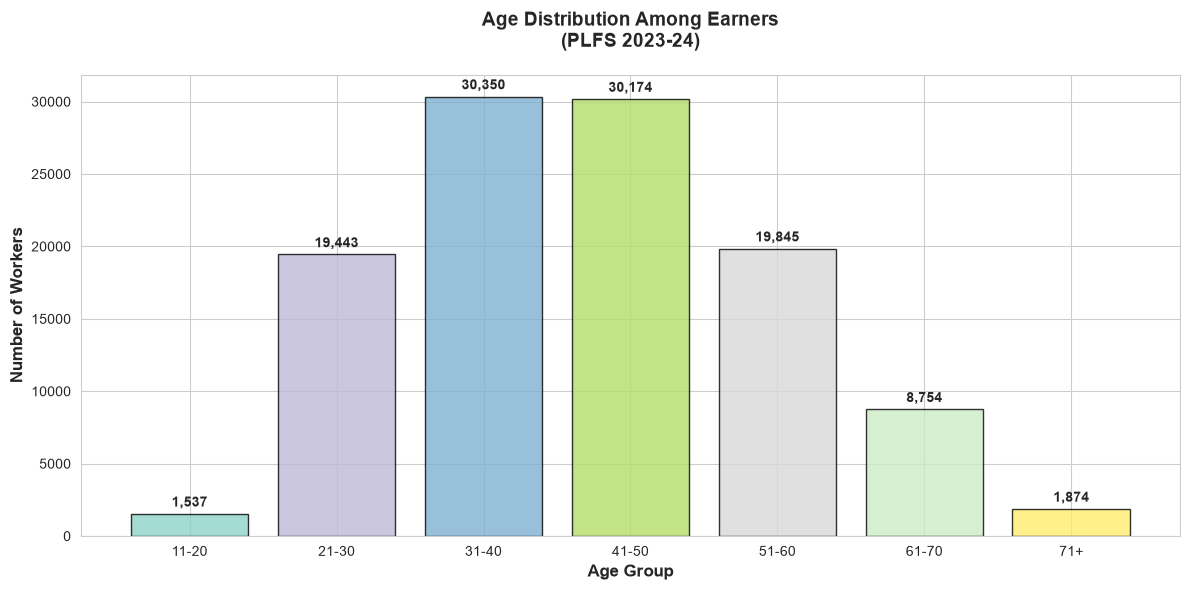

✓ Plot saved: 07_age_distribution.png


In [15]:
# Plot 7: Age Distribution
fig, ax = plt.subplots(figsize=(12, 6))

age_dist_sorted = clean_df['age_group'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(age_dist_sorted)))

bars = ax.bar(range(len(age_dist_sorted)), age_dist_sorted.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels
for i, (age_grp, count) in enumerate(age_dist_sorted.items()):
    ax.text(i, count + 500, f'{count:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Workers', fontsize=12, fontweight='bold')
ax.set_title('Age Distribution Among Earners\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(age_dist_sorted)))
ax.set_xticklabels(age_dist_sorted.index)
plt.tight_layout()
plt.savefig('../outputs/07_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 07_age_distribution.png")

In [16]:
# Age group earnings statistics
age_earnings = clean_df.groupby('age_group')['earnings'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std')
]).round(2)

print("\nAge Group Earnings Statistics:")
print("="*90)
print(age_earnings)


Age Group Earnings Statistics:
           Count      Mean   Median   Std Dev
age_group                                    
11-20       1537   8317.61   8000.0   4550.53
21-30      19443  14871.56  12000.0  11603.61
31-40      30350  18204.49  15000.0  16026.35
41-50      30174  18847.41  15000.0  17141.02
51-60      19845  20602.39  14500.0  21717.66
61-70       8754  13990.01  10000.0  15620.70
71+         1874  13361.98   8500.0  21416.49


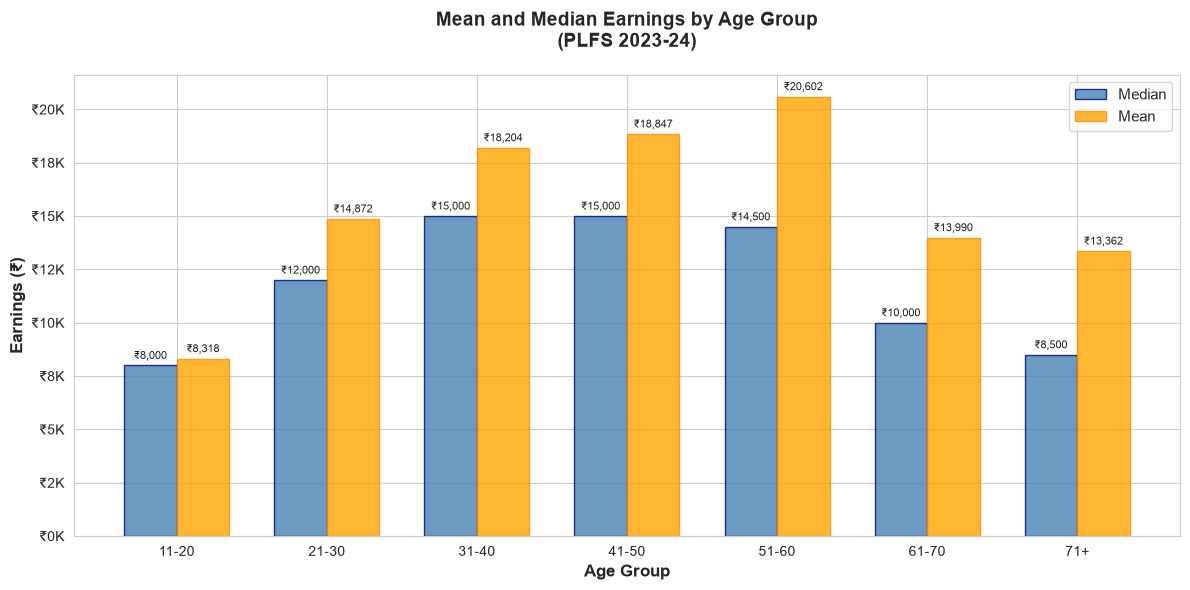

✓ Plot saved: 08_age_earnings.png


In [17]:
# Plot 8: Earnings by Age Group
fig, ax = plt.subplots(figsize=(12, 6))

age_median = clean_df.groupby('age_group')['earnings'].median()
age_mean = clean_df.groupby('age_group')['earnings'].mean()

x = np.arange(len(age_median))
width = 0.35

bars1 = ax.bar(x - width/2, age_median.values, width, label='Median', color='steelblue', edgecolor='navy', alpha=0.8)
bars2 = ax.bar(x + width/2, age_mean.values, width, label='Mean', color='orange', edgecolor='darkorange', alpha=0.8)

# Add value labels
for i, (med, mn) in enumerate(zip(age_median.values, age_mean.values)):
    ax.text(i - width/2, med + 300, f'₹{med:,.0f}', ha='center', fontsize=8)
    ax.text(i + width/2, mn + 300, f'₹{mn:,.0f}', ha='center', fontsize=8)

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Mean and Median Earnings by Age Group\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_median.index)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/08_age_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 08_age_earnings.png")

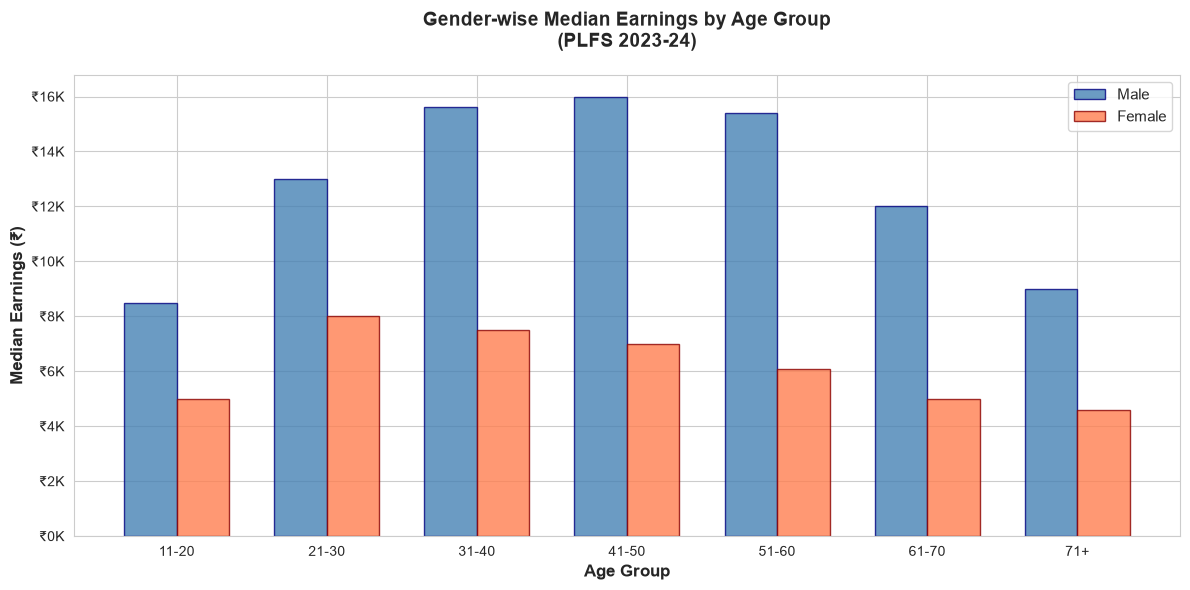

✓ Plot saved: 09_age_gender_earnings.png


In [18]:
# Plot 9: Gender-wise Earnings by Age Group
fig, ax = plt.subplots(figsize=(12, 6))

age_gender = clean_df.groupby(['age_group', 'gender'])['earnings'].median().unstack(fill_value=0)

x = np.arange(len(age_gender))
width = 0.35

if 1 in age_gender.columns:
    bars1 = ax.bar(x - width/2, age_gender[1], width, label='Male', color='steelblue', edgecolor='navy', alpha=0.8)
if 2 in age_gender.columns:
    bars2 = ax.bar(x + width/2, age_gender[2], width, label='Female', color='coral', edgecolor='darkred', alpha=0.8)

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Gender-wise Median Earnings by Age Group\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_gender.index)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/09_age_gender_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 09_age_gender_earnings.png")

In [19]:
# Employment status distribution
emp_dist = clean_df['employment_status'].value_counts().sort_values(ascending=False)

print("\nEmployment Status Distribution:")
print("="*70)
for emp_code, count in emp_dist.items():
    emp_name = employment_map.get(emp_code, f"Code {emp_code}")
    pct = (count / len(clean_df)) * 100
    print(f"{emp_name:<40} : {count:>6,} ({pct:>5.1f}%)")


Employment Status Distribution:
Self-employed (Own Account)              : 59,169 ( 52.8%)
Casual Wage (Non-Agri)                   : 45,771 ( 40.9%)
Self-employed (Employer)                 :  6,199 (  5.5%)
Unpaid Family Worker                     :    573 (  0.5%)
Regular Salaried/Wage                    :    239 (  0.2%)
Casual Wage (Agriculture)                :     26 (  0.0%)


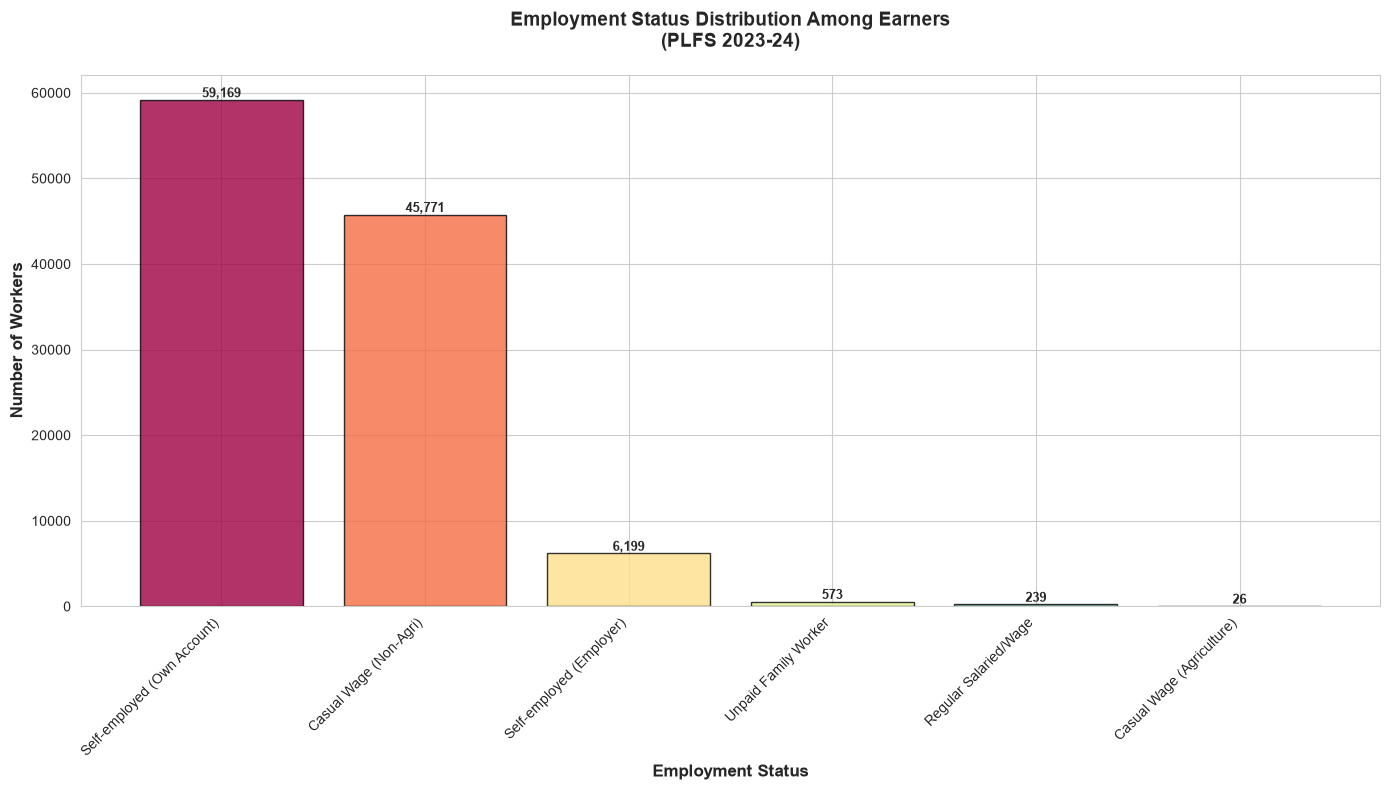

✓ Plot saved: 10_employment_distribution.png


In [20]:
# Plot 10: Employment Status Distribution
fig, ax = plt.subplots(figsize=(14, 8))

emp_names = [employment_map.get(code, f"Code {code}") for code in emp_dist.index]
emp_counts = emp_dist.values

colors = plt.cm.Spectral(np.linspace(0, 1, len(emp_names)))
bars = ax.bar(range(len(emp_names)), emp_counts, color=colors, edgecolor='black', alpha=0.8)

# Add value labels
for i, (name, count) in enumerate(zip(emp_names, emp_counts)):
    ax.text(i, count + 300, f'{count:,}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Employment Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Workers', fontsize=12, fontweight='bold')
ax.set_title('Employment Status Distribution Among Earners\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(emp_names)))
ax.set_xticklabels(emp_names, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/10_employment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 10_employment_distribution.png")

In [21]:
# Employment-wise earnings statistics
emp_earnings = clean_df.groupby('employment_status')['earnings'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std')
]).round(2)

emp_earnings['Status'] = emp_earnings.index.map(lambda x: employment_map.get(x, f"Code {x}"))
emp_earnings = emp_earnings[['Status', 'Count', 'Mean', 'Median', 'Std Dev']]
emp_earnings = emp_earnings.sort_values('Median', ascending=False)

print("\nEmployment Status - Earnings Statistics:")
print("="*110)
print(emp_earnings.to_string(index=False))


Employment Status - Earnings Statistics:
                     Status  Count     Mean  Median  Std Dev
   Self-employed (Employer)   6199 31425.02 25000.0 28627.41
     Casual Wage (Non-Agri)  45771 21858.15 15000.0 19837.50
Self-employed (Own Account)  59169 13159.39 12000.0 10011.11
      Regular Salaried/Wage    239  7569.37  5500.0  6736.62
       Unpaid Family Worker    573  6461.44  5120.0  4604.26
  Casual Wage (Agriculture)     26  3490.38  2600.0  2967.49


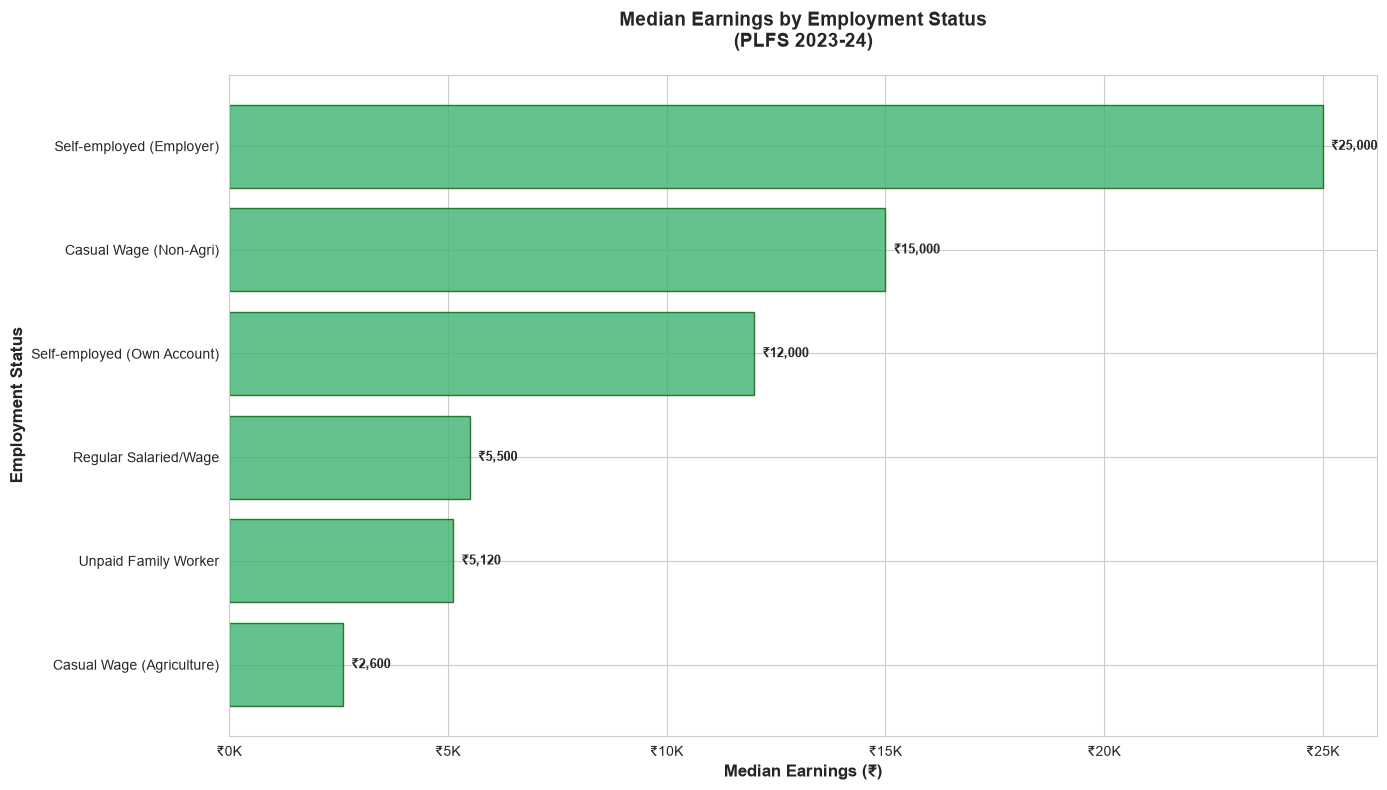

✓ Plot saved: 11_employment_earnings.png


In [22]:
# Plot 11: Earnings by Employment Status
fig, ax = plt.subplots(figsize=(14, 8))

emp_median = clean_df.groupby('employment_status')['earnings'].median().sort_values()
emp_names_sorted = [employment_map.get(code, f"Code {code}") for code in emp_median.index]

bars = ax.barh(emp_names_sorted, emp_median.values, color='mediumseagreen', edgecolor='darkgreen', alpha=0.8)

# Add value labels
for i, (name, value) in enumerate(zip(emp_names_sorted, emp_median.values)):
    ax.text(value + 200, i, f'₹{value:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Employment Status', fontsize=12, fontweight='bold')
ax.set_title('Median Earnings by Employment Status\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/11_employment_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 11_employment_earnings.png")

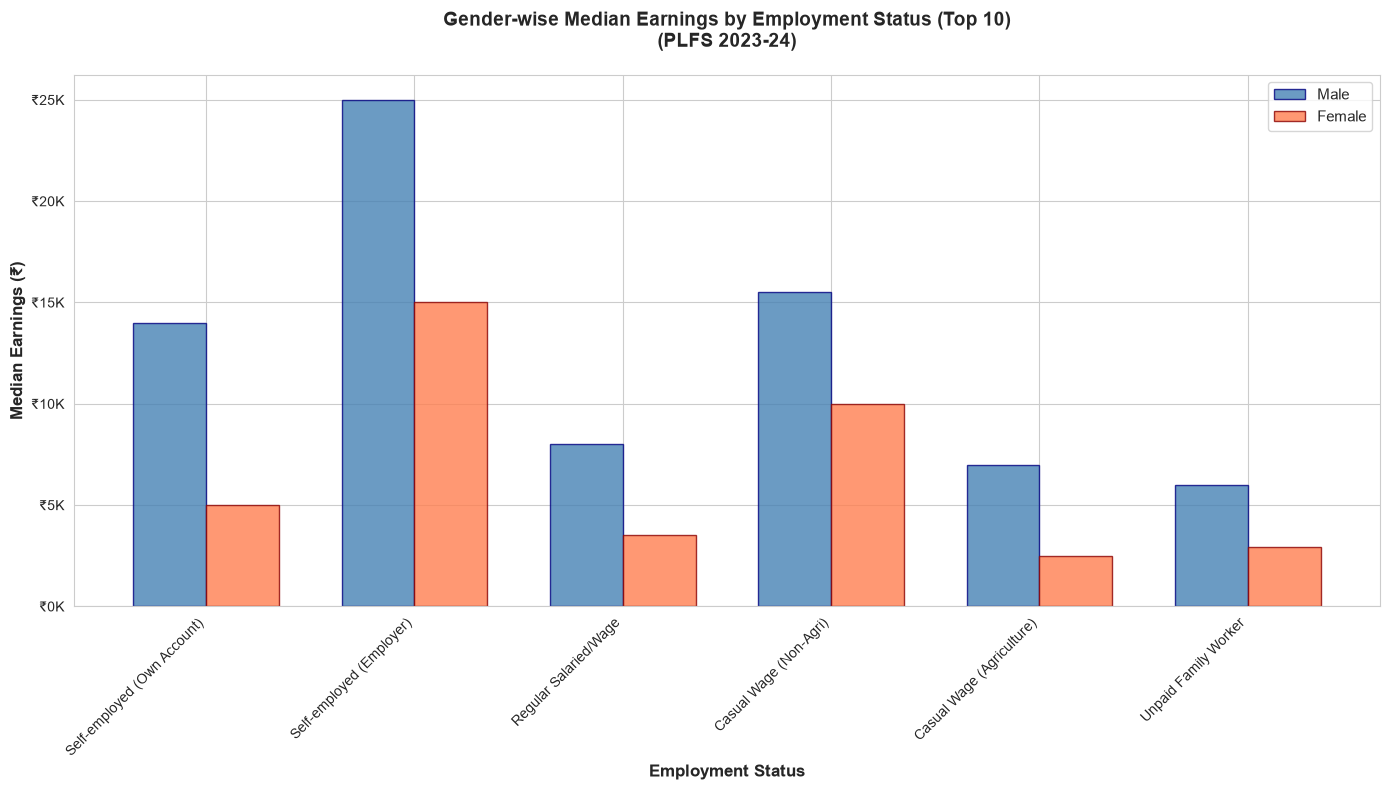

✓ Plot saved: 12_employment_gender_earnings.png


In [23]:
# Plot 12: Gender-wise Earnings by Employment Status (Top 10 statuses)
fig, ax = plt.subplots(figsize=(14, 8))

top_emp = clean_df['employment_status'].value_counts().head(10).index
emp_gender = clean_df[clean_df['employment_status'].isin(top_emp)].groupby(
    ['employment_status', 'gender']
)['earnings'].median().unstack(fill_value=0)

emp_names_top = [employment_map.get(code, f"Code {code}") for code in emp_gender.index]

x = np.arange(len(emp_names_top))
width = 0.35

if 1 in emp_gender.columns:
    bars1 = ax.bar(x - width/2, emp_gender[1], width, label='Male', color='steelblue', edgecolor='navy', alpha=0.8)
if 2 in emp_gender.columns:
    bars2 = ax.bar(x + width/2, emp_gender[2], width, label='Female', color='coral', edgecolor='darkred', alpha=0.8)

ax.set_xlabel('Employment Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Gender-wise Median Earnings by Employment Status (Top 10)\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(emp_names_top, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/12_employment_gender_earnings.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 12_employment_gender_earnings.png")

# TASK 4: CORRELATION ANALYSIS

Perform correlation analysis between relevant numerical variables.

In [24]:
# Select numerical columns for correlation
numerical_cols = [
    'age',
    'formal_education_years',
    'earnings',
    'regular_earnings',
    'self_employed_earnings'
]

# Create correlation matrix
corr_matrix = clean_df[numerical_cols].corr()

print("\nCorrelation Matrix (Pearson):")
print("="*70)
print(corr_matrix.round(4))

print("\n\nCorrelation with Earnings (Sorted):")
print("="*70)
early_corr = corr_matrix['earnings'].sort_values(ascending=False)
for var, corr_val in early_corr.items():
    if var != 'earnings':
        print(f"{var:<30} : {corr_val:>7.4f}")


Correlation Matrix (Pearson):
                           age  formal_education_years  earnings  \
age                     1.0000                 -0.3528    0.0489   
formal_education_years -0.3528                  1.0000    0.3936   
earnings                0.0489                  0.3936    1.0000   
regular_earnings        0.1763                 -0.0224    0.4079   
self_employed_earnings -0.0873                  0.4193    0.7033   

                        regular_earnings  self_employed_earnings  
age                               0.1763                 -0.0873  
formal_education_years           -0.0224                  0.4193  
earnings                          0.4079                  0.7033  
regular_earnings                  1.0000                 -0.3622  
self_employed_earnings           -0.3622                  1.0000  


Correlation with Earnings (Sorted):
self_employed_earnings         :  0.7033
regular_earnings               :  0.4079
formal_education_years         :  0.39

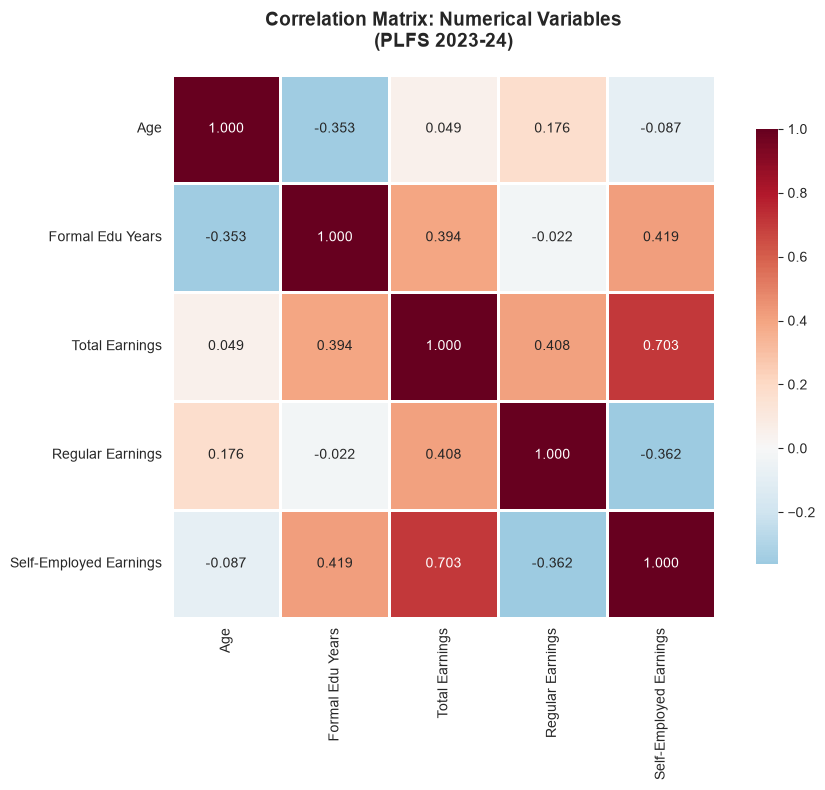

✓ Plot saved: 13_correlation_heatmap.png


In [25]:
# Plot 13: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create a more readable version of correlation matrix
corr_labels = {
    'age': 'Age',
    'formal_education_years': 'Formal Edu Years',
    'earnings': 'Total Earnings',
    'regular_earnings': 'Regular Earnings',
    'self_employed_earnings': 'Self-Employed Earnings'
}

corr_matrix_labeled = corr_matrix.copy()
corr_matrix_labeled.index = [corr_labels.get(x, x) for x in corr_matrix_labeled.index]
corr_matrix_labeled.columns = [corr_labels.get(x, x) for x in corr_matrix_labeled.columns]

sns.heatmap(
    corr_matrix_labeled,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title('Correlation Matrix: Numerical Variables\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/13_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 13_correlation_heatmap.png")

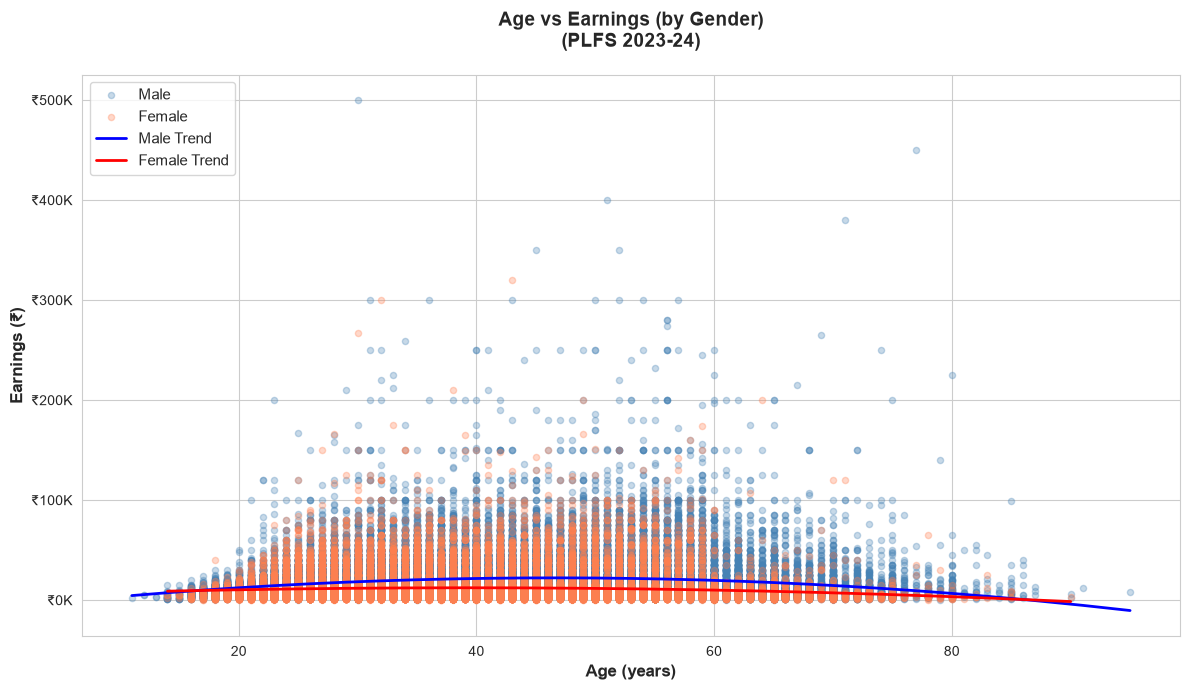

✓ Plot saved: 14_age_earnings_scatter.png


In [26]:
# Plot 14: Scatter plots - Age vs Earnings (by Gender)
fig, ax = plt.subplots(figsize=(12, 7))

# Male earners
male_df = clean_df[clean_df['gender'] == 1]
ax.scatter(male_df['age'], male_df['earnings'], alpha=0.3, s=20, color='steelblue', label='Male')

# Female earners
female_df = clean_df[clean_df['gender'] == 2]
ax.scatter(female_df['age'], female_df['earnings'], alpha=0.3, s=20, color='coral', label='Female')

# Add trend lines
z_male = np.polyfit(male_df['age'], male_df['earnings'], 2)
p_male = np.poly1d(z_male)
ax.plot(sorted(male_df['age']), p_male(sorted(male_df['age'])), "b-", linewidth=2, label='Male Trend')

z_female = np.polyfit(female_df['age'], female_df['earnings'], 2)
p_female = np.poly1d(z_female)
ax.plot(sorted(female_df['age']), p_female(sorted(female_df['age'])), "r-", linewidth=2, label='Female Trend')

ax.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Age vs Earnings (by Gender)\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/14_age_earnings_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 14_age_earnings_scatter.png")

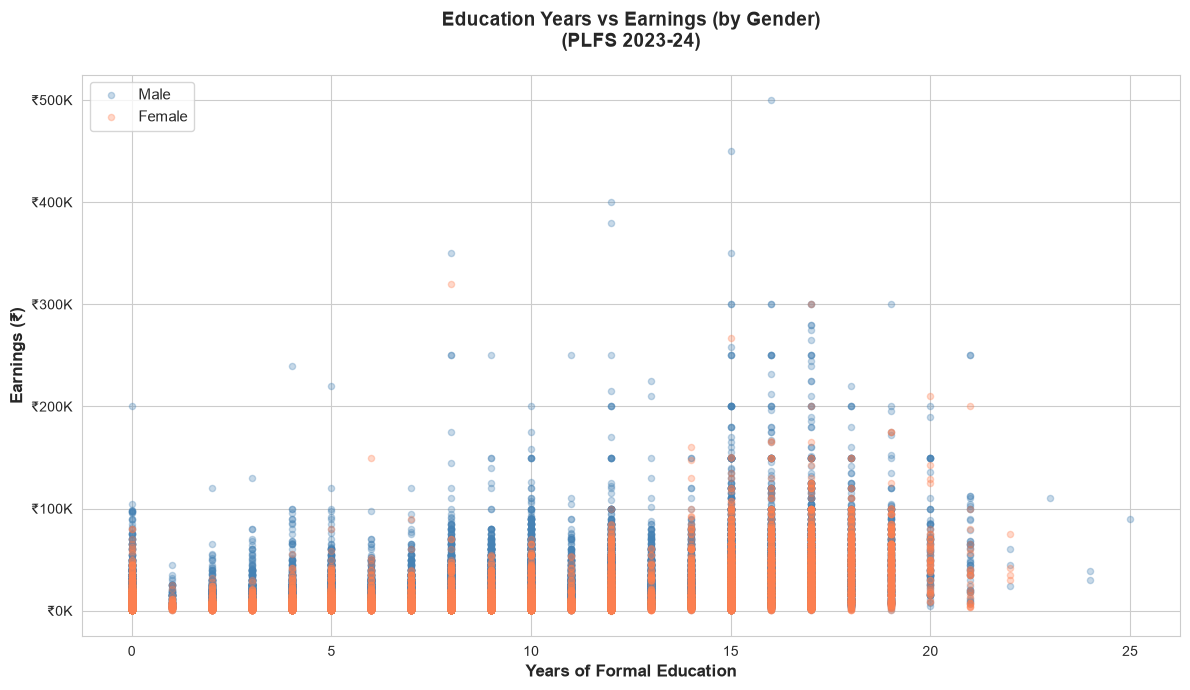

✓ Plot saved: 15_education_earnings_scatter.png


In [27]:
# Plot 15: Scatter plots - Education Years vs Earnings (by Gender)
fig, ax = plt.subplots(figsize=(12, 7))

# Male earners
male_df_edu = clean_df[clean_df['gender'] == 1]
ax.scatter(male_df_edu['formal_education_years'], male_df_edu['earnings'], 
          alpha=0.3, s=20, color='steelblue', label='Male')

# Female earners
female_df_edu = clean_df[clean_df['gender'] == 2]
ax.scatter(female_df_edu['formal_education_years'], female_df_edu['earnings'], 
          alpha=0.3, s=20, color='coral', label='Female')

ax.set_xlabel('Years of Formal Education', fontsize=12, fontweight='bold')
ax.set_ylabel('Earnings (₹)', fontsize=12, fontweight='bold')
ax.set_title('Education Years vs Earnings (by Gender)\n(PLFS 2023-24)', 
              fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/15_education_earnings_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 15_education_earnings_scatter.png")

# COMPREHENSIVE EDA SUMMARY

All visualizations are saved and ready for presentation.

In [35]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*80)

print("\n📊 DATASET OVERVIEW:")
print(f"  Total Records: {len(clean_df):,}")
print(f"  Male Workers: {(clean_df['gender']==1).sum():,} ({(clean_df['gender']==1).sum()/len(clean_df)*100:.1f}%)")
print(f"  Female Workers: {(clean_df['gender']==2).sum():,} ({(clean_df['gender']==2).sum()/len(clean_df)*100:.1f}%)")

print("\n💰 EARNINGS OVERVIEW:")
print(f"  Average Earnings: ₹{clean_df['earnings'].mean():,.2f}")
print(f"  Median Earnings: ₹{clean_df['earnings'].median():,.2f}")
print(f"  Range: ₹{clean_df['earnings'].min():,.0f} - ₹{clean_df['earnings'].max():,.0f}")

male_median = clean_df[clean_df['gender']==1]['earnings'].median()
female_median = clean_df[clean_df['gender']==2]['earnings'].median()
gap = male_median - female_median
gap_pct = (gap / male_median) * 100

print("\n⚖️ GENDER EARNINGS GAP:")
print(f"  Male Median: ₹{male_median:,.2f}")
print(f"  Female Median: ₹{female_median:,.2f}")
print(f"  Gap: ₹{gap:,.2f} ({gap_pct:.2f}%)")

print("\n📈 VISUALIZATIONS CREATED (15 Graphs):")
visualization_list = [
    "01_occupation_distribution.png - Worker count by occupation",
    "02_occupation_earnings.png - Median earnings by occupation",
    "03_occupation_gender_earnings.png - Gender comparison by occupation",
    "04_education_distribution.png - Worker count by education level",
    "05_education_earnings.png - Earnings by education level",
    "06_education_gender_earnings.png - Gender comparison by education",
    "07_age_distribution.png - Worker count by age group",
    "08_age_earnings.png - Earnings by age group",
    "09_age_gender_earnings.png - Gender comparison by age group",
    "10_employment_distribution.png - Worker count by employment status",
    "11_employment_earnings.png - Earnings by employment status",
    "12_employment_gender_earnings.png - Gender comparison by employment",
    "13_correlation_heatmap.png - Correlation matrix of numerical variables",
    "14_age_earnings_scatter.png - Scatter plot: Age vs Earnings",
    "15_education_earnings_scatter.png - Scatter plot: Education vs Earnings"
]

for i, viz in enumerate(visualization_list, 1):
    print(f"  {i:2d}. {viz}")




EXPLORATORY DATA ANALYSIS - COMPREHENSIVE SUMMARY

📊 DATASET OVERVIEW:
  Total Records: 111,977
  Male Workers: 84,398 (75.4%)
  Female Workers: 27,578 (24.6%)

💰 EARNINGS OVERVIEW:
  Average Earnings: ₹17,677.77
  Median Earnings: ₹13,260.00
  Range: ₹250 - ₹500,000

⚖️ GENDER EARNINGS GAP:
  Male Median: ₹15,000.00
  Female Median: ₹7,000.00
  Gap: ₹8,000.00 (53.33%)

📈 VISUALIZATIONS CREATED (15 Graphs):
   1. 01_occupation_distribution.png - Worker count by occupation
   2. 02_occupation_earnings.png - Median earnings by occupation
   3. 03_occupation_gender_earnings.png - Gender comparison by occupation
   4. 04_education_distribution.png - Worker count by education level
   5. 05_education_earnings.png - Earnings by education level
   6. 06_education_gender_earnings.png - Gender comparison by education
   7. 07_age_distribution.png - Worker count by age group
   8. 08_age_earnings.png - Earnings by age group
   9. 09_age_gender_earnings.png - Gender comparison by age group
  10.